In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(r'clustering_workout.csv')
df.head(2)

,CustomerID,Purchase_Frequency,Spend,Monthly_Visits,Loyalty_Score
0,1,5.993428,55.789308,5,8.485273
1,2,4.723471,44.433809,2,3.457637


In [3]:
X = df.drop('CustomerID', axis=1)
X.head(2)

,Purchase_Frequency,Spend,Monthly_Visits,Loyalty_Score
0,5.993428,55.789308,5,8.485273
1,4.723471,44.433809,2,3.457637


In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaling = StandardScaler()

for y in X.columns:
    X[y] = scaling.fit_transform(X[[y]])
X.head()

,Purchase_Frequency,Spend,Monthly_Visits,Loyalty_Score
0,0.527074,0.313055,1.138726,1.102854
1,-0.136138,-0.270206,-0.555246,-0.832925
2,0.684761,0.872967,1.138726,0.016088
3,1.599023,1.737018,0.009411,-0.744025
4,-0.236291,-0.230213,1.703383,1.480504


In [10]:
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score,davies_bouldin_score

In [29]:
wcss = []
clus = range(1,15)

for cl in clus:
    model = KMeans(n_clusters=cl, random_state=3)
    model.fit(X)
    wcss.append(model.inertia_)

In [19]:
import matplotlib.pyplot as plt

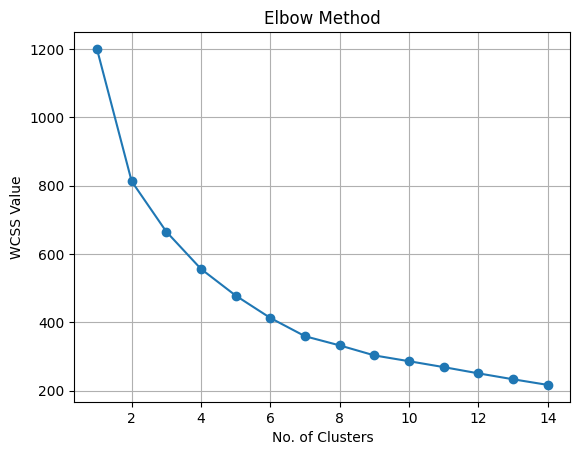

In [30]:
plt.plot(clus,wcss, marker='o')
plt.grid(True)
plt.title('Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS Value')
plt.show()

In [50]:
model = KMeans(n_clusters=7, random_state=3)
y_pred_Kmen = model.fit_predict(X)

print(f'Silhouette score : {silhouette_score(X,y_pred_Kmen)} | Davies Score : {davies_bouldin_score(X,y_pred_Kmen)}')

Silhouette score : 0.26227206350435356 | Davies Score : 1.1045674293032748


In [51]:
model = AgglomerativeClustering(n_clusters=7)
y_pred_hier = model.fit_predict(X)

print(f'Silhouette score : {silhouette_score(X,y_pred_hier)} | Davies Score : {davies_bouldin_score(X,y_pred_hier)}')

Silhouette score : 0.22946382389924347 | Davies Score : 1.1167020906575937


In [52]:
model = GaussianMixture(n_components=7, random_state=3)
y_pred_gmm = model.fit_predict(X)

print(f'Silhouette score : {silhouette_score(X,y_pred_gmm)} | Davies Score : {davies_bouldin_score(X,y_pred_gmm)}')

Silhouette score : 0.15103828399722155 | Davies Score : 1.4032796154129161


In [47]:
df['KNN_cluster'] = y_pred_Kmen
df['Hier_cluster'] = y_pred_hier
df['GMM_cluster'] = y_pred_gmm

In [49]:
df.head(10)

,CustomerID,Purchase_Frequency,Spend,Monthly_Visits,Loyalty_Score,KNN_cluster,Hier_cluster,GMM_cluster
0,1,5.993428,55.789308,5,8.485273,4,1,4
1,2,4.723471,44.433809,2,3.457637,0,0,0
2,3,6.295377,66.690239,5,5.662709,6,1,6
3,4,8.046060,83.512448,3,3.688530,5,2,5
4,5,4.531693,45.212425,6,9.466113,1,5,1
5,6,4.531726,45.903898,6,3.333671,1,5,1
6,7,8.158426,87.972581,3,4.866911,5,2,5
7,8,6.534869,62.390838,5,8.854572,4,1,4
8,9,4.061051,43.345999,2,8.577402,3,6,3
9,10,6.085120,59.840238,4,2.674913,6,0,6


In [65]:
model = DBSCAN(eps=1,min_samples=6)
y_pred = model.fit_predict(X)

print(f'Silhouette score : {silhouette_score(X,y_pred)} | Davies Score : {davies_bouldin_score(X,y_pred)}')


Silhouette score : 0.31754464959452045 | Davies Score : 7.6013404333107495


In [66]:
df['DBS_cluster'] = y_pred

In [70]:
df['KNN_cluster'].value_counts()

KNN_cluster
4    62
3    54
0    45
6    40
2    38
1    31
5    30
Name: count, dtype: int64

In [69]:
df.tail(20)

,CustomerID,Purchase_Frequency,Spend,Monthly_Visits,Loyalty_Score,KNN_cluster,Hier_cluster,GMM_cluster,DBS_cluster
280,281,5.227035,53.962829,3,9.186641,4,4,4,0
281,282,6.324261,61.166174,3,7.022802,4,4,4,0
282,283,8.172034,84.884246,2,8.463581,5,2,5,0
283,284,2.524369,36.597154,1,8.910810,3,6,3,0
284,285,9.266067,93.569999,4,6.145951,5,2,5,-1
285,286,1.095824,12.199347,1,5.657017,2,3,3,-1
286,287,4.696430,44.667494,7,4.873847,1,5,1,0
287,288,6.176634,57.517122,2,3.852519,0,0,5,0
288,289,5.561984,59.771516,3,4.911364,0,0,6,0
289,290,3.754601,33.265590,3,7.964917,3,6,3,0
